# System Configuration

## Library Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

## Utility Functions

In [19]:
# Complex Gaussian distribution
def complex_normal(mean, std, size):
  real = np.random.normal(np.real(mean), std/np.sqrt(2), size)
  imag = np.random.normal(np.imag(mean), std/np.sqrt(2), size)
  return real + 1j * imag

# dB to Power conversion
def db2pow(db):
    return 10 ** (db / 10)

# Channel capacity for y = Hx + n
def chan_cap(H, SNR):
  I = np.eye(H.shape[0])
  return np.log2(np.linalg.det(I + db2pow(SNR) * H.conj().T @ H))

## Parameter Values

In [20]:
# All values are in dB

n1 = 0         # E|w1|^2
n2 = -25       # E|w2|^2
snr = 3        # E[|x|^2 / |w1|^2]
inr = 40       # E[|v|^2 / |w1|^2]
s2n = 60       # E[|t| / |w1|^2]

In [21]:
N = 50                          # Input Dimension

inp_bw = list(range(5, 25))     # Input bandwidth
int_bw = list(range(35, 45))    # Interference bandwidth

K = 1000                        # Number of iterations

In [22]:
w1_var = db2pow(n1)/N           # Variance of noise w1
w2_var = db2pow(n2)/N           # Variance of noise w2
inp_var = db2pow(snr + n1)/N    # Input Variance
int_var = db2pow(inr + n1)/N    # Interference Variance
t = db2pow(s2n + n1)            # Saturation level of non-linear function phi()

gamma_w1 = 1 / w1_var  # Inverse variance of noise w1
gamma_w2 = 1 / w2_var  # Inverse variance of noise w2

## Non-linear function

In [23]:
# Non-linear function
def phi(x):
  return np.sqrt(t) * np.tanh(x/np.sqrt(t))

# Derivative of Non-linear function
def phi_der(x):
  return 1 - np.tanh(x/np.sqrt(t))**2

# Non-linear System Model (Python Class)

In [24]:
class system_model:

  def __init__(self, N, inp_bw, int_bw, inp_std, int_std, n1_std, n2_std, phi=phi):
    """
    Parameters:
    - N: Size of the input & interference signal.
    - inp_bw: Frequency indices where input is present.
    - int_bw: Frequency indices where interference is present.
    - inp_std: Standard deviation of input frequency vector.
    - int_std: Standard deviation of interference frequency vector.
    - n1_std: Standard deviation of noise w_1.
    - n2_std: Standard deviation of noise w_2.
    - phi: Nonlinear function.
    """
    self.N = N
    self.inp_bw = inp_bw
    self.int_bw = int_bw
    self.inp_std = inp_std
    self.int_std = int_std
    self.n1_std = n1_std
    self.n2_std = n2_std
    self.phi = phi

  def run(self):
    """Simulates the described system"""
    # Input signal in time domain
    self.x = complex_normal(0, self.inp_std, self.N)
    self.b = np.zeros(self.N, dtype=complex)
    self.b[self.inp_bw] = 1
    self.s = self.b * self.x  # Input frequency domain signal
    self.t = np.fft.ifft(self.s)  # Input time domain signal

    # Interference signal in time domain
    self.u = complex_normal(0, self.int_std, self.N)
    self.bu = np.zeros(self.N, dtype=complex)
    self.bu[self.int_bw] = 1
    self.u = self.bu * self.u  # Interference frequency domain signal
    self.v = np.fft.ifft(self.u)  # Interference time domain signal

    # Noise signals
    w_1 = complex_normal(0, self.n1_std, self.N)
    w_2 = complex_normal(0, self.n2_std, self.N)

    # Final output
    phi_out = self.phi(self.t + self.v + w_1)
    self.y = phi_out + w_2
    return self.t, self.v, self.y

# Linear Approximation (Python Class)

In [25]:
class linear_approximation:

  def __init__(self, y, v, n1_std, n2_std, phi=phi, phi_der=phi_der):
    """
    Parameters:
    - y: Size of the input & interference signal.
    - v: Frequency indices where input is present.
    - n1_std: Standard deviation of noise w_1.
    - n2_std: Standard deviation of noise w_2.
    - phi: Nonlinear function.
    - phi_der: Derivative of Nonlinear function.
    """
    self.y = y
    self.v = v
    self.n1_std = n1_std
    self.n2_std = n2_std
    self.phi = phi
    self.phi_der = phi_der

  def run(self):
    """Returns the parameters of the linear system approximation"""
    phi_der_v = self.phi_der(self.v)
    self.sigma = np.sqrt(np.square(self.n1_std * phi_der_v) + np.square(self.n2_std))
    self.z = (self.y - self.phi(self.v)) / self.sigma
    self.a = phi_der_v / self.sigma
    return self.sigma, self.z, self.a

# VAMP-SLM (Python Class)

In [26]:
class VAMP_SLM:

  def __init__(self, A, y, x_var, gamma_w, K):
    """
    Parameters:
    - A: Measurement matrix (MxN)
    - y: Noisy observation (Mx1)
    - x_var: Variance of x
    - gamma_w: Inverse variance of noise w
    - K: Number of iterations
    """
    self.A = A
    self.y = y
    self.x_var = x_var
    self.gamma_w = gamma_w
    self.K = K

    self.M, self.N = A.shape  # Dimensions
    self.U, self.s, self.Vh = np.linalg.svd(A, full_matrices=False)  # SVD

    # Initial algorithm parameters
    self.r1 = np.zeros(self.N)  # Pseudo-measurement of x
    self.gamma1 = 0.1  # Inverse variance of Pseudo-measurement noise


  def g1_denoiser(self, r, gamma):
    """
    Denoiser (customized based on prior knowledge of x)
    """
    xhat = r * self.x_var / (self.x_var + (1 / gamma))
    alpha = self.x_var / (self.x_var + (1 / gamma))
    return xhat, alpha


  def g2_LMMSE(self, r, gamma):
    """
    LMMSE estimator
    """
    D = np.diag(1 / (self.gamma_w * self.s**2 + gamma))
    y_tilde = self.gamma_w * np.diag(self.s).T @ self.U.T @ self.y
    x_hat = self.Vh.T @ (D @ (y_tilde + gamma * (self.Vh @ r)))
    alpha = np.mean(gamma / (self.gamma_w * self.s**2 + gamma))
    return x_hat, alpha


  def run(self):
    """
    VAMP-SLM.
    """
    for k in range(self.K):
        # Denoising
        x1, alpha1 = self.g1_denoiser(self.r1, self.gamma1)
        r2 = (x1 - alpha1 * self.r1) / (1 - alpha1)
        gamma2 = self.gamma1 * (1 - alpha1) / alpha1

        # LMMSE estimation
        x2, alpha2 = self.g2_LMMSE(r2, gamma2)
        self.r1 = (x2 - alpha2 * r2) / (1 - alpha2)
        self.gamma1 = gamma2 * (1 - alpha2) / alpha2
    return x1

# System Simulation

In [27]:
non_lin_sys = system_model(N, inp_bw, int_bw, np.sqrt(inp_var), np.sqrt(int_var), np.sqrt(w1_var), np.sqrt(w2_var))
t, v, y = non_lin_sys.run()
x_true = non_lin_sys.x
b = non_lin_sys.b

lin_approx = linear_approximation(y, v,  np.sqrt(w1_var), np.sqrt(w2_var))
sigma, z, a = lin_approx.run()

H = np.diag(a) @ np.fft.ifft(np.diag(b), axis=0)

In [28]:
x1 = VAMP_SLM(H, z, inp_var, 1, K).run()
mse = np.mean(np.absolute(x1 - x_true) ** 2)

print("Mean Squared Error (MSE):", mse)
print("Normalized Mean Squared Error (NMSE):", (mse / np.mean(np.absolute(x_true) ** 2)))
print("True Norm of x:", np.linalg.norm(x_true))
print("Estimated Norm of x:", np.linalg.norm(x1))
# print(x_true)
# print(x1)

Mean Squared Error (MSE): 0.12513350328928138
Normalized Mean Squared Error (NMSE): 3.1154007555424466
True Norm of x: 1.4171468097130966
Estimated Norm of x: 2.1243760999925523


# Channel Capacity

In [29]:
U, S, Vh = np.linalg.svd(H.conj().T @ H)

print("Singular values:\n", S)

Singular values:
 [8.60714718e-01 8.57768038e-01 7.77782749e-01 6.01219336e-01
 5.61590461e-01 4.95360869e-01 4.63133130e-01 4.13181504e-01
 3.24331433e-01 2.05075310e-01 1.72820917e-01 6.90147848e-02
 5.09956729e-02 2.20006994e-02 1.12722063e-02 6.74945236e-03
 3.99890671e-03 1.19547661e-04 1.81662373e-05 3.55381649e-06
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17 6.00754596e-17 6.00754596e-17
 6.00754596e-17 6.00754596e-17]


In [30]:
C1 = np.real(chan_cap(H, snr))
print(f"Channel Capacity: {C1:.4f} bits per channel use")

C2 = np.sum(np.log2(1 + db2pow(snr) * S))
print(f"Channel Capacity: {C2:.4f} bits per channel use")

Channel Capacity: 11.3511 bits per channel use
Channel Capacity: 11.3511 bits per channel use


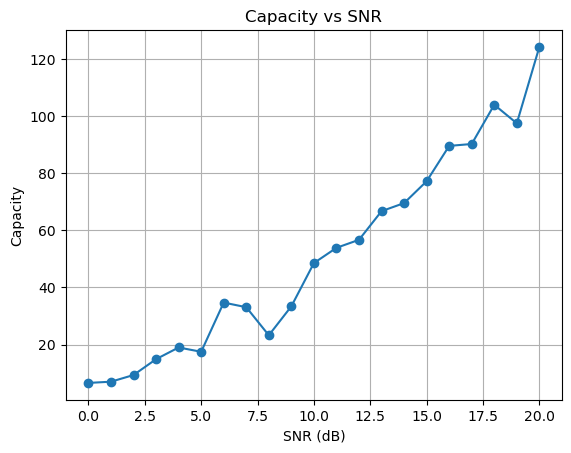

In [31]:
SNR = np.arange(0, 21, 1)
C = []

inr = 40
int_var = db2pow(inr + n1)/N

for snr in SNR:
  inp_var = db2pow(snr + n1)/N

  non_lin_sys = system_model(N, inp_bw, int_bw, np.sqrt(inp_var), np.sqrt(int_var), np.sqrt(w1_var), np.sqrt(w2_var))
  t, v, y = non_lin_sys.run()
  x_true = non_lin_sys.x
  b = non_lin_sys.b

  lin_approx = linear_approximation(y, v,  np.sqrt(w1_var), np.sqrt(w2_var))
  sigma, z, a = lin_approx.run()

  H = np.diag(a) @ np.fft.ifft(np.diag(b), axis=0)
  U, S, Vh = np.linalg.svd(H.conj().T @ H)

  c = np.sum(np.log2(1 + db2pow(snr) * S))
  C.append(c)

plt.plot(SNR, C, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("Capacity")
plt.title("Capacity vs SNR")
plt.grid()
plt.show()

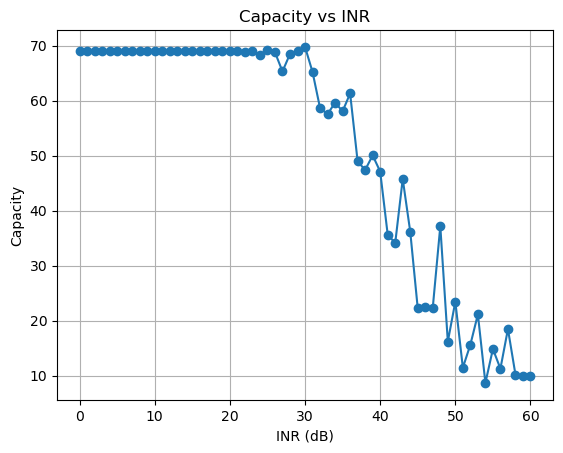

In [32]:
INR = np.arange(0, 61, 1)
C = []

snr = 10
inp_var = db2pow(snr + n1)/N

for inr in INR:
  int_var = db2pow(inr + n1)/N

  non_lin_sys = system_model(N, inp_bw, int_bw, np.sqrt(inp_var), np.sqrt(int_var), np.sqrt(w1_var), np.sqrt(w2_var))
  t, v, y = non_lin_sys.run()
  x_true = non_lin_sys.x
  b = non_lin_sys.b

  lin_approx = linear_approximation(y, v,  np.sqrt(w1_var), np.sqrt(w2_var))
  sigma, z, a = lin_approx.run()

  H = np.diag(a) @ np.fft.ifft(np.diag(b), axis=0)
  U, S, Vh = np.linalg.svd(H.conj().T @ H)

  c = np.sum(np.log2(1 + db2pow(snr) * S))
  C.append(c)

plt.plot(INR, C, marker='o')
plt.xlabel("INR (dB)")
plt.ylabel("Capacity")
plt.title("Capacity vs INR")
plt.grid()
plt.show()

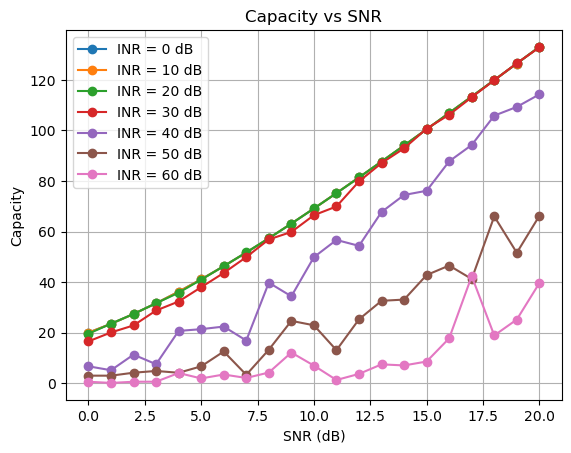

In [33]:
SNR = np.arange(0, 21, 1)
INR = np.arange(0, 61, 10)
C = []

for inr in INR:
  c = []
  for snr in SNR:
    inp_var = db2pow(snr + n1)/N
    int_var = db2pow(inr + n1)/N

    non_lin_sys = system_model(N, inp_bw, int_bw, np.sqrt(inp_var), np.sqrt(int_var), np.sqrt(w1_var), np.sqrt(w2_var))
    t, v, y = non_lin_sys.run()
    x_true = non_lin_sys.x
    b = non_lin_sys.b

    lin_approx = linear_approximation(y, v,  np.sqrt(w1_var), np.sqrt(w2_var))
    sigma, z, a = lin_approx.run()

    H = np.diag(a) @ np.fft.ifft(np.diag(b), axis=0)
    U, S, Vh = np.linalg.svd(H.conj().T @ H)

    c.append(np.sum(np.log2(1 + db2pow(snr) * S)))

  C.append(c)

for i in range(len(INR)):
  plt.plot(SNR, C[i], marker='o', label=f"INR = {INR[i]} dB")

plt.xlabel("SNR (dB)")
plt.ylabel("Capacity")
plt.title("Capacity vs SNR")
plt.grid()
plt.legend()
plt.show()

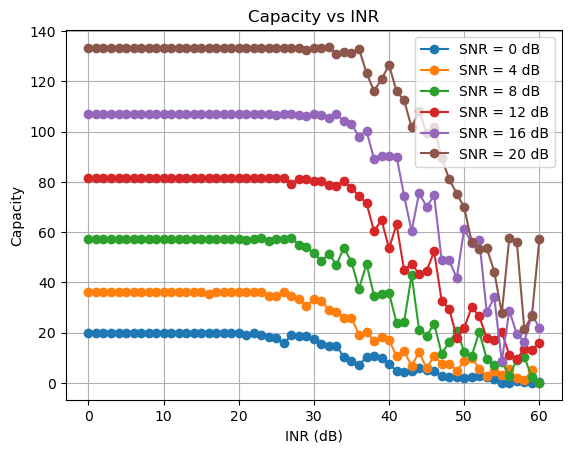

In [34]:
SNR = np.arange(0, 21, 4)
INR = np.arange(0, 61, 1)
C = []

for snr in SNR:
  c = []
  for inr in INR:
    inp_var = db2pow(snr + n1)/N
    int_var = db2pow(inr + n1)/N

    non_lin_sys = system_model(N, inp_bw, int_bw, np.sqrt(inp_var), np.sqrt(int_var), np.sqrt(w1_var), np.sqrt(w2_var))
    t, v, y = non_lin_sys.run()
    x_true = non_lin_sys.x
    b = non_lin_sys.b

    lin_approx = linear_approximation(y, v,  np.sqrt(w1_var), np.sqrt(w2_var))
    sigma, z, a = lin_approx.run()

    H = np.diag(a) @ np.fft.ifft(np.diag(b), axis=0)
    U, S, Vh = np.linalg.svd(H.conj().T @ H)

    c.append(np.sum(np.log2(1 + db2pow(snr) * S)))

  C.append(c)

for i in range(len(SNR)):
  plt.plot(INR, C[i], marker='o', label=f"SNR = {SNR[i]} dB")

plt.xlabel("INR (dB)")
plt.ylabel("Capacity")
plt.title("Capacity vs INR")
plt.grid()
plt.legend()
plt.show()

$U^H|B|^2U   |A|^2$